In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

# Set plotting styles
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Pipeline environments initialized successfully.")

Pipeline environments initialized successfully.


In [2]:
X_raw = pd.read_csv('../data/train_values.csv')
y_raw = pd.read_csv('../data/train_labels.csv')

# Merge features and labels on building_id to ensure clean synchronization during filtering
df_raw = pd.merge(X_raw, y_raw, on='building_id')
df_open_input = pd.read_csv('../data/NepalEarhquakeDamage2015.csv')

print(f"Dataset loaded. Total shape: {df_raw.shape}")
df_raw.head()

Dataset loaded. Total shape: (260601, 40)


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [3]:
df_open_input["plinth_area_sq_ft"].min()
df_raw["area_percentage"].max()

100

In [4]:
# 1. Retain your targeted ground truth label
target = 'damage_grade'

# 2. STRIP LOCATION DATA: Drop all direct or proxy geographical variables
# This prevents the model from associating location and irrelevant data with damage risk.
non_structural_cols = [
    'building_id', 
    'geo_level_1_id', 
    'geo_level_2_id', 
    'geo_level_3_id', 
    'legal_ownership_status',
    'position'
    ]
secondary_use_cols = [col for col in df_raw.columns if col.startswith('has_secondary_use')]
cols_to_drop = non_structural_cols + secondary_use_cols
df_filtered = df_raw.drop(columns=cols_to_drop)

# 3. ADVANCED EXTRACTION: Create spatial-free structural ratios
# Tree-based models process structural aspect ratios and density well when explicitly defined
df_filtered['height_to_floor_ratio'] = df_filtered['height_percentage'] / (df_filtered['count_floors_pre_eq'] + 1e-5)
df_filtered['area_to_height_ratio'] = df_filtered['area_percentage'] / (df_filtered['height_percentage'] + 1e-5)

# Highly fragile combinations
df_filtered['is_highly_vulnerable_material'] = (
    (df_filtered['has_superstructure_mud_mortar_stone'] == 1) | 
    (df_filtered['has_superstructure_mud_mortar_brick'] == 1)
).astype(int)

# Highly resilient combinations
df_filtered['is_engineered_material'] = (
    (df_filtered['has_superstructure_rc_engineered'] == 1) | 
    (df_filtered['has_superstructure_cement_mortar_brick'] == 1)
).astype(int)

# Create an engineering hazard index for the building framework itself
df_filtered['structural_age_stress'] = df_filtered['age'] * df_filtered['count_floors_pre_eq']

print(f"Shape after removing geographical IDs: {df_filtered.shape}")

Shape after removing geographical IDs: (260601, 28)


In [5]:
# Separate structural attributes from our resilience indicator
X = df_filtered.drop(columns=[target])
y = df_filtered[target]

# XGBoost handles categorical data natively if typed as 'category' or via One-Hot Encoding
# We'll use pandas get_dummies for clear, immutable feature tracking
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Shift target labels if needed (XGBoost expects classes starting at 0, Nepal data uses 1, 2, 3)
if y.min() == 1:
    y = y - 1

print(categorical_cols)
print(f"Encoded feature space shape: {X_encoded.shape}")
X

C:\Users\User\AppData\Local\Temp\ipykernel_9648\1832182626.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'plan_configuration']
Encoded feature space shape: (260601, 45)


,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,plan_configuration,...,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,count_families,height_to_floor_ratio,area_to_height_ratio,is_highly_vulnerable_material,is_engineered_material,structural_age_stress
0,2,30,6,5,t,r,n,f,q,d,...,0,0,0,0,1,2.499988,1.199998,1,0,60
1,2,10,8,7,o,r,n,x,q,d,...,0,0,0,0,1,3.499983,1.142856,1,0,20
2,2,10,5,5,t,r,n,f,x,d,...,0,0,0,0,1,2.499988,0.999998,1,0,20
3,2,10,6,5,t,r,n,f,x,d,...,1,0,0,0,1,2.499988,1.199998,1,0,20
4,3,30,8,9,t,r,n,f,x,d,...,0,0,0,0,1,2.999990,0.888888,0,0,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,1,55,6,3,n,r,n,f,j,q,...,0,0,0,0,1,2.999970,1.999993,1,0,55
260597,2,0,6,5,t,r,n,f,q,d,...,0,0,0,0,1,2.499988,1.199998,1,0,0
260598,3,55,6,7,t,r,q,f,q,d,...,0,0,0,0,1,2.333326,0.857142,1,0,165
260599,2,10,14,6,t,r,x,v,s,d,...,0,0,0,0,1,2.999985,2.333329,0,1,20


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Matrix Shape: {X_train.shape}")
print(f"Testing Matrix Shape:  {X_test.shape}")

# Hyperparameter search for a stronger XGBoost baseline
param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'n_estimators': [150, 250, 350],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ),
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=0
)

from sklearn.utils.class_weight import compute_class_weight

classes_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weight_dict = dict(zip(np.unique(y_train), classes_weights))
sample_weights = y_train.map(weight_dict)

search.fit(X_train, y_train, sample_weight=sample_weights)
print("Best parameters:", search.best_params_)
print("Best CV macro F1:", round(search.best_score_, 4))

Training Matrix Shape: (208480, 45)
Testing Matrix Shape:  (52121, 45)


In [ ]:
best_params = search.best_params_

model = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    **best_params,
    reg_lambda=1.0,
    reg_alpha=0.1
)

model.fit(X_train, y_train, sample_weight=sample_weights)
print("Model training complete.")
print("Final parameters:", model.get_params())

Model training complete.
Final parameters: {'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 1.0, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 350, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 1.0, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.9, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [ ]:
y_pred = model.predict(X_test)

print("--- Accuracy Evaluation ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("--- Classification Matrix ---")
print(classification_report(y_test, y_pred, target_names=['Low Damage', 'Medium Damage', 'High Damage']))

# Optional: inspect where the model struggles
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


--- Accuracy Evaluation ---
Overall Accuracy: 0.5242

--- Classification Matrix ---
               precision    recall  f1-score   support

   Low Damage       0.39      0.70      0.50      5025
Medium Damage       0.68      0.40      0.50     29652
  High Damage       0.46      0.69      0.55     17444

     accuracy                           0.52     52121
    macro avg       0.51      0.60      0.52     52121
 weighted avg       0.58      0.52      0.52     52121


Confusion Matrix:
[[ 3525   799   701]
 [ 4649 11828 13175]
 [  826  4648 11970]]


C:\Users\User\AppData\Local\Temp\ipykernel_2192\1521920693.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


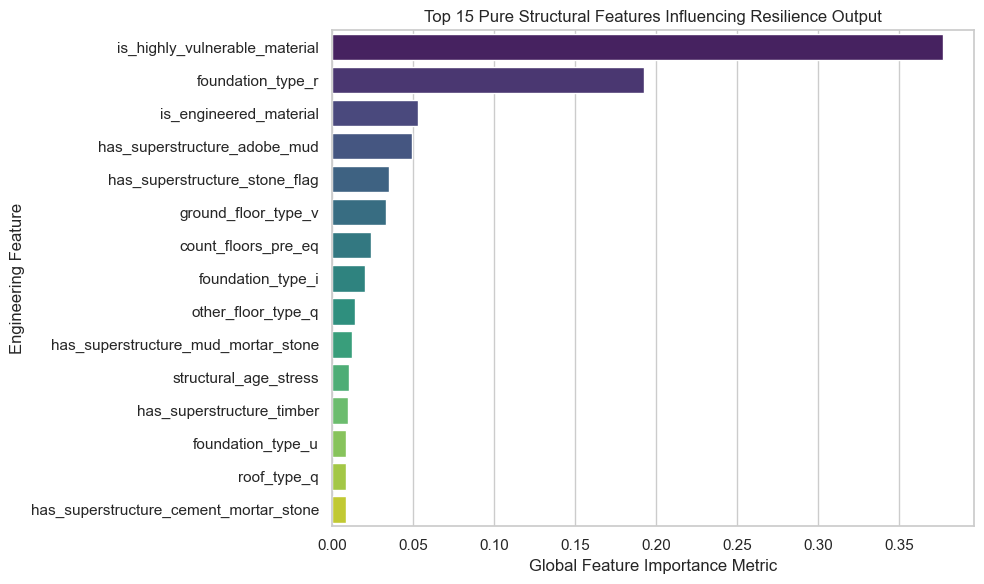

In [ ]:
importance = model.feature_importances_
feature_names = X_encoded.columns

feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 15 Pure Structural Features Influencing Resilience Output')
plt.xlabel('Global Feature Importance Metric')
plt.ylabel('Engineering Feature')
plt.tight_layout()
plt.show()

In [ ]:
def calculate_resilience_score(trained_model, feature_matrix):
    """
    Translates raw XGBoost class probabilities into a continuous 
    Structural Seismic Resilience Score scaled from 0 (Extremely Fragile) to 100 (Highly Resilient).
    """
    # Get probability matrices: shape (N, 3)
    # Col 0: P(Low Damage), Col 1: P(Medium Damage), Col 2: P(High Damage)
    probabilities = trained_model.predict_proba(feature_matrix)
    
    # Mathematical Expected Value Weighting Matrix
    # We assign maximal value to Low Damage survival, moderate value to partial damage, and 0 to collapse.
    low_damage_prob = probabilities[:, 0]
    med_damage_prob = probabilities[:, 1]
    
    # Linear scale calculation
    resilience_scores = (low_damage_prob * 100) + (med_damage_prob * 45)
    
    return np.round(resilience_scores, 2)

# Apply to test set
X_test_scored = X_test.copy()
X_test_scored['Resilience_Score'] = calculate_resilience_score(model, X_test)

# Let's see how our structural engineering configurations rank!
# We'll isolate key engineering features alongside the final generated score
inspection_cols = [
    'count_floors_pre_eq', 
    'age', 
    'is_highly_vulnerable_material', 
    'is_engineered_material', 
    'Resilience_Score'
]

print("--- Sample Structural Resilience Scores ---")
print(X_test_scored[inspection_cols].head(15))

--- Sample Structural Resilience Scores ---
        count_floors_pre_eq  age  is_highly_vulnerable_material  \
124536                    3   60                              1   
112152                    1   20                              1   
93613                     1    0                              1   
204895                    1   25                              1   
37356                     2   30                              1   
256180                    2    0                              1   
163106                    1   20                              1   
200003                    2   15                              0   
135048                    1   30                              1   
75728                     2   35                              1   
72203                     2    5                              0   
126264                    1   10                              1   
92769                     2    5                              1   
23664             

In [ ]:
import joblib
import json

# 1. Save the trained XGBoost model pipeline
joblib.dump(model, 'seismic_resilience_xgb.pkl')

# 2. Save the exact column structure expected after One-Hot Encoding
# Your inference script will use this to align input features perfectly
model_features = X_encoded.columns.tolist()
with open('model_features.json', 'w') as f:
    json.dump(model_features, f)

print("Artifacts successfully exported!")
print(f"Model saved as: 'models/seismic_resilience_xgb.pkl'")
print(f"Feature schema saved as: 'models/model_features.json' ({len(model_features)} features)")

Artifacts successfully exported!
Model saved as: 'models/seismic_resilience_xgb.pkl'
Feature schema saved as: 'models/model_features.json' (43 features)


In [ ]:
import json
import pandas as pd
import numpy as np

def predict_single_building_resilience(raw_input_dict, trained_model, expected_features_list):
    """
    Takes a high-level user dictionary, processes it to strip geolocation biases,
    matches training structural features, and calculates the Resilience Score.
    """
    # 1. Convert single dictionary input to a DataFrame row
    df_input = pd.DataFrame([raw_input_dict])
    
    # 2. Re-calculate your advanced engineering extraction layers
    df_input['height_to_floor_ratio'] = df_input['height_percentage'] / (df_input['count_floors_pre_eq'] + 1e-5)
    df_input['area_to_height_ratio'] = df_input['area_percentage'] / (df_input['height_percentage'] + 1e-5)

    def _bool_flag(col):
        return pd.Series(df_input.get(col, 0), index=df_input.index) == 1

    df_input['is_highly_vulnerable_material'] = (
        (_bool_flag('has_superstructure_mud_mortar_stone')) | 
        (_bool_flag('has_superstructure_mud_mortar_brick'))
    ).astype(int)

    df_input['is_engineered_material'] = (
        _bool_flag('has_superstructure_rc_engineered') |
        _bool_flag('has_superstructure_cement_mortar_brick')
    ).astype(int)

    df_input['structural_age_stress'] = df_input['age'] * df_input['count_floors_pre_eq']
    
    # 3. Handle One-Hot Encoding for categorical features
    categorical_cols = ['foundation_type', 'roof_type', 'ground_floor_type']
    df_encoded = pd.get_dummies(df_input, columns=[c for c in categorical_cols if c in df_input.columns])
    
    # 4. Critical Schema Alignment: Ensure all 43 training features match perfectly
    # Any categorical dummy missing from this specific user input gets zeroed out
    for col in expected_features_list:
        if col not in df_encoded.columns:
            df_encoded[col] = 0
            
    # Force identical column ordering
    df_final = df_encoded[expected_features_list]
    
    # 5. Extract probabilities from the model
    probs = trained_model.predict_proba(df_final)
    
    # 6. Apply your optimized resilience index scaling formula
    resilience_score = (probs[:, 0] * 100) + (probs[:, 1] * 45)
    
    return round(float(resilience_score[0]), 2)

print("Inference engine function compiled.")

Inference engine function compiled.


In [ ]:
# ==========================================
# CELL 12: INTERACTIVE TESTING SANDBOX
# ==========================================

# Pull our schema list generated from our encoding step
expected_features = X_encoded.columns.tolist()

# TEST CASE A: An old, multi-story traditional masonry house
building_profile_A = {
    'count_floors_pre_eq': 3,
    'age': 55,
    'area_percentage': 6,
    'height_percentage': 8,
    'foundation_type': 'r',                  # 'r' stands for mud mortar stone/brick
    'roof_type': 'n',                        # 'n' stands for non-engineered slate/tile
    'ground_floor_type': 'f',                # 'f' stands for mud/earth floor
    'has_superstructure_mud_mortar_stone': 1,
    'has_superstructure_rc_engineered': 0,
    'has_superstructure_cement_mortar_brick': 0
}

# TEST CASE B: Modern, low-rise reinforced concrete structure
building_profile_B = {
    'count_floors_pre_eq': 1,
    'age': 2,
    'area_percentage': 12,
    'height_percentage': 4,
    'foundation_type': 'i',                  # 'i' stands for reinforced concrete footprint
    'roof_type': 'x',                        # 'x' stands for reinforced concrete roof
    'ground_floor_type': 'v',                # 'v' stands for concrete/brick floor
    'has_superstructure_mud_mortar_stone': 0,
    'has_superstructure_rc_engineered': 1,
    'has_superstructure_cement_mortar_brick': 1
}

# Compute scores
score_A = predict_single_building_resilience(building_profile_A, model, expected_features)
score_B = predict_single_building_resilience(building_profile_B, model, expected_features)

print("====================================================")
print(f" PROFILE A RESILIENCE SCORE: {score_A} / 100")
print(" Description: Multi-story aging mud-stone infrastructure.")
print("====================================================")
print(f" PROFILE B RESILIENCE SCORE: {score_B} / 100")
print(" Description: Modern low-profile reinforced engineered concrete.")
print("====================================================")

 PROFILE A RESILIENCE SCORE: 31.38 / 100
 Description: Multi-story aging mud-stone infrastructure.
 PROFILE B RESILIENCE SCORE: 96.96 / 100
 Description: Modern low-profile reinforced engineered concrete.
